Phân tích mô tả (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Cài đặt phong cách đồ thị
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
# Đọc dữ liệu
df = pd.read_csv('creditcard_processed.csv', index_col=0)
display(df.head())


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


Mật độ phân bố theo thời gian dạng các điểm
Biểu đồ Scatter plot thể hiện phân bố của đối tượng gian lận.

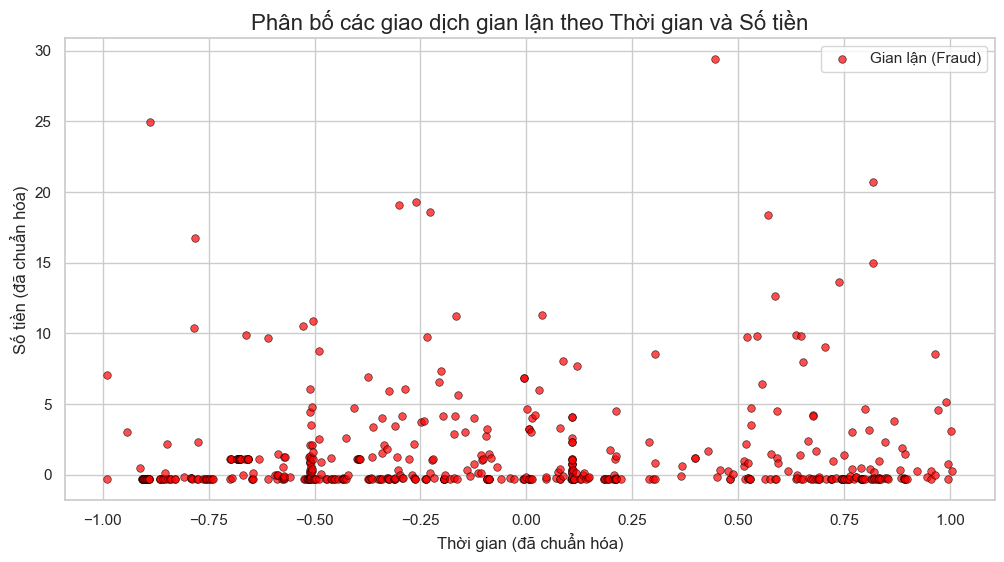

In [3]:
# Lọc dữ liệu gian lận và bình thường
fraud_df = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0]

plt.figure(figsize=(12, 6))
plt.scatter(fraud_df['scaled_time'], fraud_df['scaled_amount'], alpha=0.7, color='red', s=30, label='Gian lận (Fraud)', edgecolor='black', linewidth=0.5)
plt.title('Phân bố các giao dịch gian lận theo Thời gian và Số tiền', fontsize=16)
plt.xlabel('Thời gian (đã chuẩn hóa)', fontsize=12)
plt.ylabel('Số tiền (đã chuẩn hóa)', fontsize=12)
plt.legend()
plt.show()


Biểu đồ mật độ xác suất của các đặc trưng chính
Thể hiện sự khác biệt phân bố thống kê giữa các giao dịch bình thường và gian lận (V14, V12, V10 là các biến tương quan mạnh).

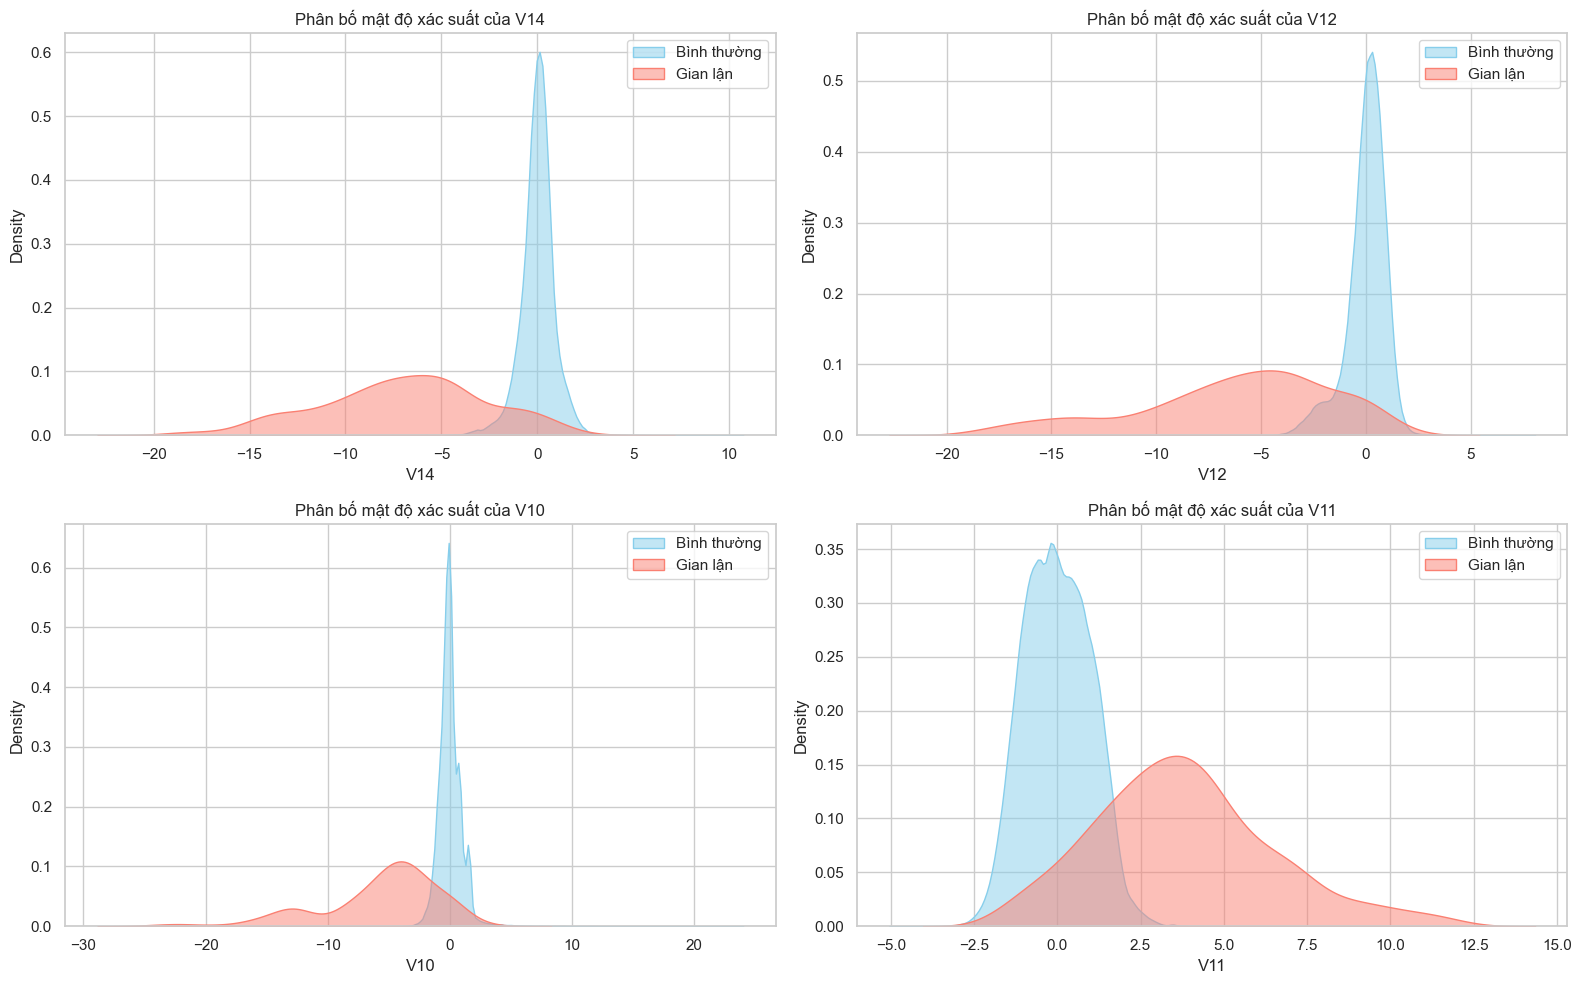

In [4]:
# Vẽ KDE plot cho các đặc trưng tương quan mạnh
features = ['V14', 'V12', 'V10', 'V11']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(normal_df[feature], label='Bình thường', fill=True, color='skyblue', ax=axes[i], alpha=0.5)
    sns.kdeplot(fraud_df[feature], label='Gian lận', fill=True, color='salmon', ax=axes[i], alpha=0.5)
    axes[i].set_title(f'Phân bố mật độ xác suất của {feature}', fontsize=12)
    axes[i].legend()

plt.tight_layout()
plt.show()


Biểu đồ mật độ xác suất giữa các điểm (Pairplot)

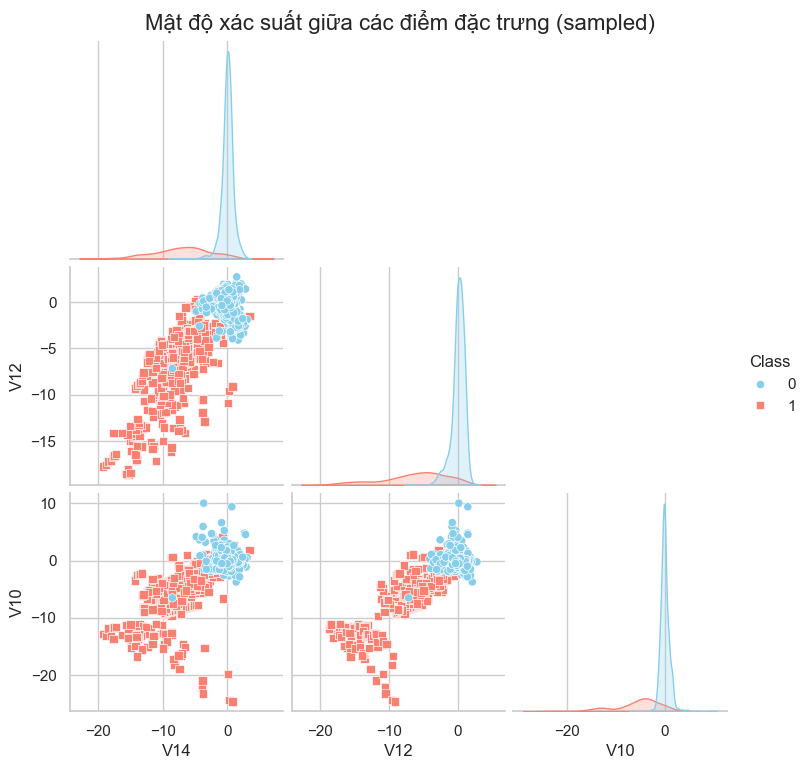

In [5]:
# Lấy mẫu một lượng nhỏ dữ liệu để pairplot chạy nhanh hơn
sample_df = pd.concat([fraud_df, normal_df.sample(len(fraud_df) * 3, random_state=42)])

sns.pairplot(sample_df[['V14', 'V12', 'V10', 'Class']], hue='Class', palette={0:'skyblue', 1:'salmon'}, markers=['o', 's'], corner=True)
plt.suptitle('Mật độ xác suất giữa các điểm đặc trưng (sampled)', y=1.02, fontsize=16)
plt.show()
